In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitaba

# Bellabeat Smart Device Usage Analysis
## Unlocking Growth Opportunities for Women's Wellness

### 1.1 Business Scenario
Bellabeat is a high-tech manufacturer of health-focused products for women. Although they are a successful small company, they have the potential to become a larger player in the global smart device market. 

**Objective:** Analyze smart device fitness data from non-Bellabeat users to identify consumer usage trends. Apply these insights to guide Bellabeat’s marketing strategy and unlock new growth opportunities.

**Key Stakeholders:** 
* Urška Sršen (Cofounder and Chief Creative Officer)
* Sando Mur (Cofounder and Executive Team Member)
* Bellabeat Marketing Analytics Team

## 2. Data Source Description

To understand consumer habits, this analysis utilizes public-domain smart device datasets. A quick overview of the dataset structure is summarized below:

| Attribute | Value |
| :--- | :--- |
| **Data Source** | Kaggle FitBit Fitness Tracker Data (via Mobius)  |
| **Sample Size** | 33 Unique Users   |
| **Tracking Period** | March 2016 – May 2016 |
| **Licensing** | CC0: Public Domain  |
| **Core Files Used** | `dailyActivity_merged.csv` |

### 2.1 Dataset Context & Content
* **Comprehensive Tracking:** The dataset contains personal fitness tracking data from eligible Fitbit users who consented to share minute-level outputThis includes physical activity, heart rate, and sleep monitoring
* **Data Organization:** The data is organized across multiple CSV files containing metrics for daily activity, steps, sleep, and calories


# * Import Libraries


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Data

In [29]:
df= pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')


# Data Exploration

In [30]:
df.shape

(940, 15)

In [31]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

In [32]:
df.head(5)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [33]:
df.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

# Data Cleaning

In [34]:
df['Id']=df['Id'].astype(str)
df['ActivityDate']=pd.to_datetime(df['ActivityDate'],format='%m/%d/%Y')
df.dtypes

Id                                  object
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object

In [35]:
df.columns=df.columns.str.lower()
df.columns

Index(['id', 'activitydate', 'totalsteps', 'totaldistance', 'trackerdistance',
       'loggedactivitiesdistance', 'veryactivedistance',
       'moderatelyactivedistance', 'lightactivedistance',
       'sedentaryactivedistance', 'veryactiveminutes', 'fairlyactiveminutes',
       'lightlyactiveminutes', 'sedentaryminutes', 'calories'],
      dtype='object')

In [36]:
df.rename(columns={
    'activitydate': 'activity_date', 
    'totalsteps': 'total_steps', 
    'totaldistance': 'total_distance',
    'trackerdistance': 'tracker_distance',
    'loggedactivitiesdistance': 'logged_activities_distance', 
    'veryactivedistance': 'very_active_distance',
    'moderatelyactivedistance': 'moderately_active_distance', 
    'lightactivedistance': 'light_active_distance',
    'sedentaryactivedistance': 'sedentary_active_distance', 
    'veryactiveminutes': 'very_active_minutes', 
    'fairlyactiveminutes': 'fairly_active_minutes',
    'lightlyactiveminutes': 'lightly_active_minutes', 
    'sedentaryminutes': 'sedentary_minutes'
}, inplace=True)

df.columns

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories'],
      dtype='object')

In [37]:
unique_users_count = df['id'].nunique()

print(f"Total number of unique users: {unique_users_count}")

Total number of unique users: 33


In [38]:
df['activity_date'] = pd.to_datetime(df['activity_date'])

start_date = df['activity_date'].min()
end_date = df['activity_date'].max()

print(f" Data Analysis Period:")
print(f"  Start Date: {start_date}")
print(f"   End Date:   {end_date}")

 Data Analysis Period:
  Start Date: 2016-04-12 00:00:00
   End Date:   2016-05-12 00:00:00


In [39]:
df.isnull().sum() 

id                            0
activity_date                 0
total_steps                   0
total_distance                0
tracker_distance              0
logged_activities_distance    0
very_active_distance          0
moderately_active_distance    0
light_active_distance         0
sedentary_active_distance     0
very_active_minutes           0
fairly_active_minutes         0
lightly_active_minutes        0
sedentary_minutes             0
calories                      0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
numeric_cols = df.select_dtypes(include='number').columns

has_invalid = (df[numeric_cols] <= -1).any()

invalid_columns = has_invalid[has_invalid == True]
print(invalid_columns)

Series([], dtype: bool)


In [42]:
df['activity_date'].nunique()

31

In [43]:
df['id'].value_counts()

id
1503960366    31
1624580081    31
1844505072    31
1927972279    31
2022484408    31
2320127002    31
2026352035    31
4020332650    31
2873212765    31
4445114986    31
4319703577    31
4388161847    31
8378563200    31
6962181067    31
5553957443    31
4702921684    31
4558609924    31
8877689391    31
8583815059    31
8053475328    31
7086361926    31
1644430081    30
5577150313    30
3977333714    30
6290855005    29
8792009665    29
6117666160    28
7007744171    26
6775888955    26
3372868164    20
8253242879    19
2347167796    18
4057192912     4
Name: count, dtype: int64

# Feature Creation

In [44]:
df['day_of_week'] = df['activity_date'].dt.day_name()

df['n_day_of_week'] = df['activity_date'].dt.weekday

df[['activity_date', 'day_of_week', 'n_day_of_week']].head()

,activity_date,day_of_week,n_day_of_week
0,2016-04-12,Tuesday,1
1,2016-04-13,Wednesday,2
2,2016-04-14,Thursday,3
3,2016-04-15,Friday,4
4,2016-04-16,Saturday,5


# Analysis

In [45]:
df.describe()

,activity_date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,n_day_of_week
count,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,2016-04-26 06:53:37.021276672,7637.910638,5.489702,5.475351,0.108171,1.502681,0.567543,3.340819,0.001606,21.164894,13.564894,192.812766,991.210638,2303.609574,2.918085
min,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-19 00:00:00,3789.750000,2.620000,2.620000,0.000000,0.000000,0.000000,1.945000,0.000000,0.000000,0.000000,127.000000,729.750000,1828.500000,1.000000
50%,2016-04-26 00:00:00,7405.500000,5.245000,5.245000,0.000000,0.210000,0.240000,3.365000,0.000000,4.000000,6.000000,199.000000,1057.500000,2134.000000,3.000000
75%,2016-05-04 00:00:00,10727.000000,7.712500,7.710000,0.000000,2.052500,0.800000,4.782500,0.000000,32.000000,19.000000,264.000000,1229.500000,2793.250000,5.000000
max,2016-05-12 00:00:00,36019.000000,28.030001,28.030001,4.942142,21.920000,6.480000,10.710000,0.110000,210.000000,143.000000,518.000000,1440.000000,4900.000000,6.000000
std,NaN,5087.150742,3.924606,3.907276,0.619897,2.658941,0.883580,2.040655,0.007346,32.844803,19.987404,109.174700,301.267437,718.166862,1.942379


In [46]:
#sedentary:less than 6000 on average
#active: between 6000 and  12000 on average
#very active :more than 12000 on average

id_avg_step = df.groupby('id')['total_steps'].mean().sort_values(ascending=False)

id_avg_step = id_avg_step.to_frame()

conditions = [
    (id_avg_step['total_steps'] < 6000),
    (id_avg_step['total_steps'] >= 6000) & (id_avg_step['total_steps'] <= 12000),
    (id_avg_step['total_steps'] > 12000)
]

values = ['sedentary', 'active', 'very active']

id_avg_step['activity_level'] = np.select(conditions, values, default='unknown')
id_activity_level =id_avg_step['activity_level']
df['activity_level'] = df['id'].map(id_activity_level)
print(id_avg_step.head())
print(df['activity_level'].value_counts())

             total_steps activity_level
id                                     
8877689391  16040.032258    very active
8053475328  14763.290323    very active
1503960366  12116.741935    very active
2022484408  11370.645161         active
7007744171  11323.423077         active
activity_level
active         542
sedentary      305
very active     93
Name: count, dtype: int64


In [59]:
steps_calories_corr = df['total_steps'].corr(df['calories'])
print(f"\nPearson correlation coefficient (Steps vs Calories): r = {steps_calories_corr:.2f}")


Pearson correlation coefficient (Steps vs Calories): r = 0.59


# creating visualistation

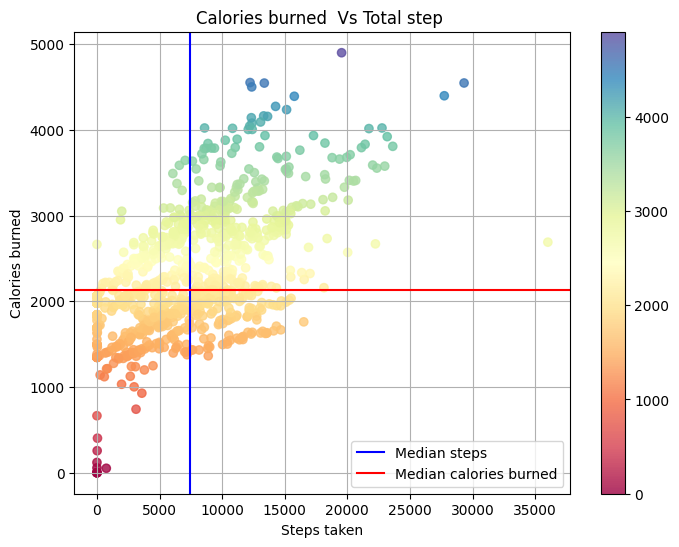

In [47]:
#correlation between steps and calories burned

plt.style.use("default")
plt.figure(figsize=(8,6)) 

plt.scatter(df.total_steps, df.calories, 
            alpha = 0.8, c = df.calories, 
            cmap = "Spectral")

median_steps = df['total_steps'].median()
median_calories = df['calories'].median()

plt.colorbar(orientation = "vertical")
plt.axvline(median_steps, color = "Blue", label = "Median steps")
plt.axhline(median_calories, color = "Red", label = "Median calories burned")

plt.xlabel("Steps taken")
plt.ylabel("Calories burned")
plt.title("Calories burned  Vs Total step ")
plt.grid(True)
plt.legend()
plt.show()

* **Positive Correlation:** There is a strong positive correlation between the total number of steps taken and calories burned(Pearson's r = 0.59),confirming that keeping moving drastically increases energy expenditure.


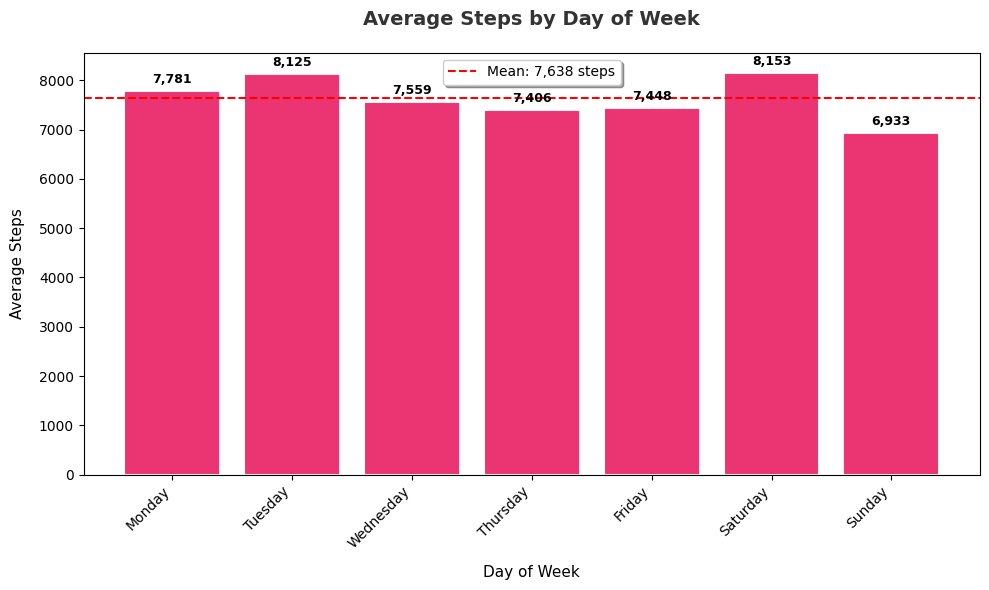

In [48]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

avg_daily_steps = (df.groupby('day_of_week', observed=False)['total_steps']
                   .mean()
                   .reindex(day_order)) 
fig, ax = plt.subplots(figsize=(10, 6))

bars = plt.bar(
    avg_daily_steps.index, 
    avg_daily_steps.values, 
    color='#E91E63',          
    edgecolor='white',        
    linewidth=1.5,
    alpha=0.9
)

avg_steps = df['total_steps'].mean()
plt.axhline(y=avg_steps, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {avg_steps:,.0f} steps')

plt.title('Average Steps by Day of Week', fontsize=14, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Day of Week', fontsize=11, labelpad=10)
plt.ylabel('Average Steps', fontsize=11, labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{height:,.0f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

* **The 10,000 Steps Gap:** The average daily steps taken by users is approximately 7,637, which falls short of the universally recommended 10,000 steps health benchmark.

day_of_week
Monday       90.9
Tuesday      92.1
Wednesday    90.9
Thursday     89.1
Friday       95.5
Saturday     93.9
Sunday       91.7
Name: count, dtype: float64


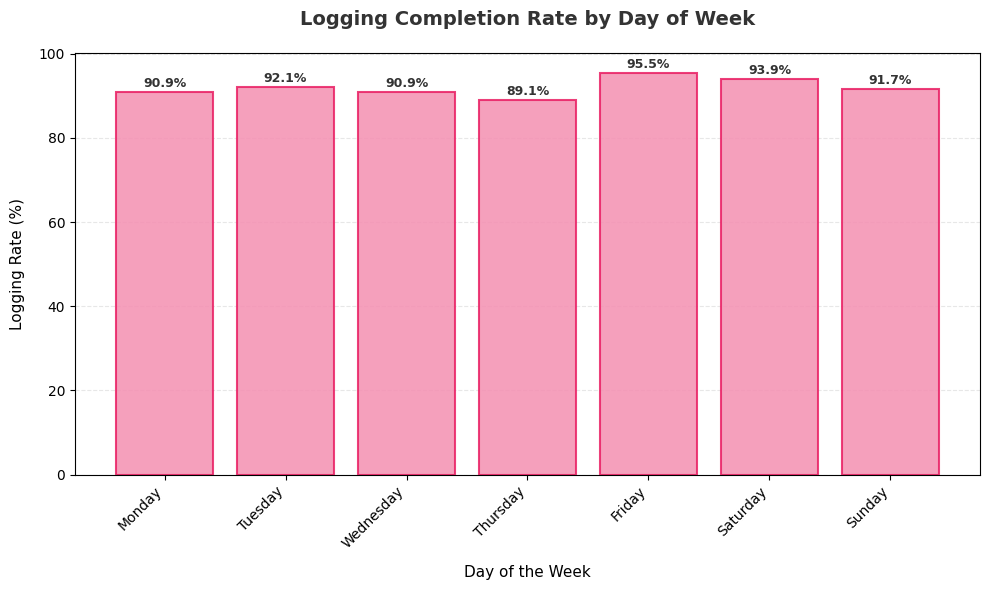

Summary of Logging Behavior:
Highest logging rate: Friday (95.5%)
Lowest logging rate: Thursday (89.1%)


In [54]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. احسبي كام مرة كل يوم في الأسبوع ظهر فعلياً في الفترة الزمنية للداتا
calendar_days = pd.date_range(start=df['activity_date'].min(), 
                                end=df['activity_date'].max(), 
                                freq='D')
weekday_occurrences = calendar_days.day_name().value_counts().reindex(day_order)

# 2. العدد الخام زي ما كان (للمقارنة)
daily_usage_raw = df['day_of_week'].value_counts().reindex(day_order)

# 3. الـ normalized rate = متوسط عدد اللوجات لكل مرة ظهر فيها اليوم دا في التقويم
daily_usage_normalized = daily_usage_raw / weekday_occurrences

# 4. (اختياري وأقوى) نسبة الاكتمال كنسبة مئوية من أقصى حد ممكن
# أقصى حد ممكن = عدد ظهور اليوم × عدد المستخدمين الكلي
unique_users_count = df['id'].nunique()
max_possible = weekday_occurrences * unique_users_count
completion_rate = (daily_usage_raw / max_possible) * 100

print(completion_rate.round(1))
fig, ax = plt.subplots(figsize=(10, 6))

bars = plt.bar(
    completion_rate.index,
    completion_rate.values,
    color='#F48FB1',
    edgecolor='#E91E63',
    linewidth=1.5,
    alpha=0.85
)

plt.title('Logging Completion Rate by Day of Week', 
          fontsize=14, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Day of the Week', fontsize=11, labelpad=10)
plt.ylabel('Logging Rate (%)', fontsize=11, labelpad=10)  # <-- الاسم اتغير عشان يعكس المعنى الصح

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
              f'{height:.1f}%',
              ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

print("Summary of Logging Behavior:")
print(f"Highest logging rate: {completion_rate.idxmax()} ({completion_rate.max():.1f}%)")
print(f"Lowest logging rate: {completion_rate.idxmin()} ({completion_rate.min():.1f}%)")


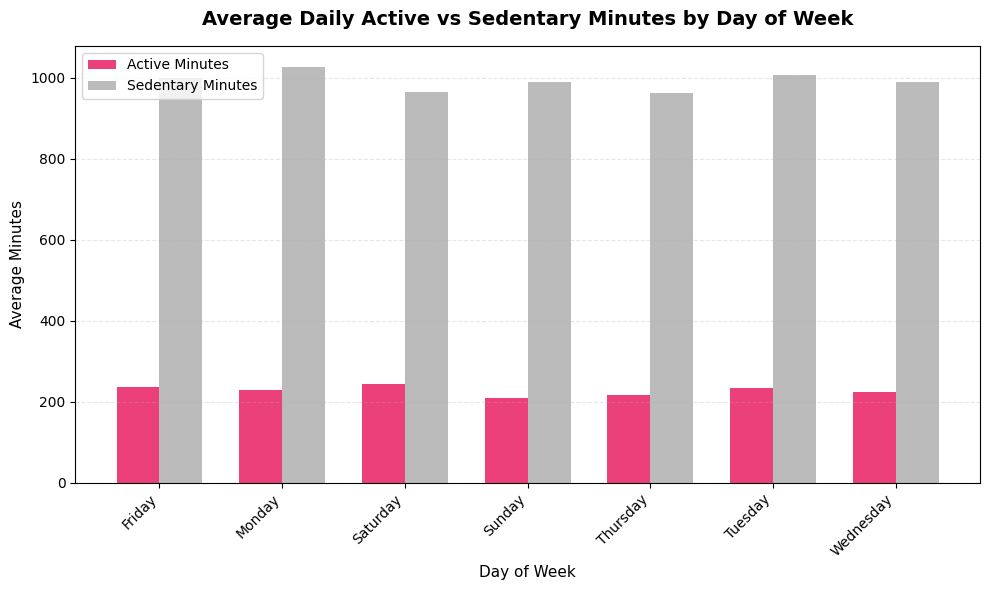

In [50]:
import matplotlib.pyplot as plt

cols_to_fix = {
    'veryactiveminutes': 'very_active_minutes',
    'fairlyactiveminutes': 'fairly_active_minutes',
    'lightlyactiveminutes': 'lightly_active_minutes',
    'sedentaryminutes': 'sedentary_minutes'
}
df.rename(columns={old: new for old, new in cols_to_fix.items() if old in df.columns}, inplace=True)


daily_activity_comparison = df.groupby('day_of_week', observed=False).agg({
    'very_active_minutes': 'mean',
    'fairly_active_minutes': 'mean',
    'lightly_active_minutes': 'mean',
    'sedentary_minutes': 'mean'
}).reset_index()

daily_activity_comparison['total_active_minutes'] = (
    daily_activity_comparison['very_active_minutes'] + 
    daily_activity_comparison['fairly_active_minutes'] + 
    daily_activity_comparison['lightly_active_minutes']
)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(daily_activity_comparison))
width = 0.35

plt.bar(x, daily_activity_comparison['total_active_minutes'], width, label='Active Minutes', color='#E91E63', alpha=0.85)
plt.bar([i + width for i in x], daily_activity_comparison['sedentary_minutes'], width, label='Sedentary Minutes', color='#9E9E9E', alpha=0.7)

plt.title('Average Daily Active vs Sedentary Minutes by Day of Week', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=11)
plt.ylabel('Average Minutes', fontsize=11)
plt.xticks([i + width/2 for i in x], daily_activity_comparison['day_of_week'], rotation=45, ha='right')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

* **Sedentary Lifestyle:** On average, users spend more than 16 hours (approx. 991 minutes) per day being sedentary (inactive).

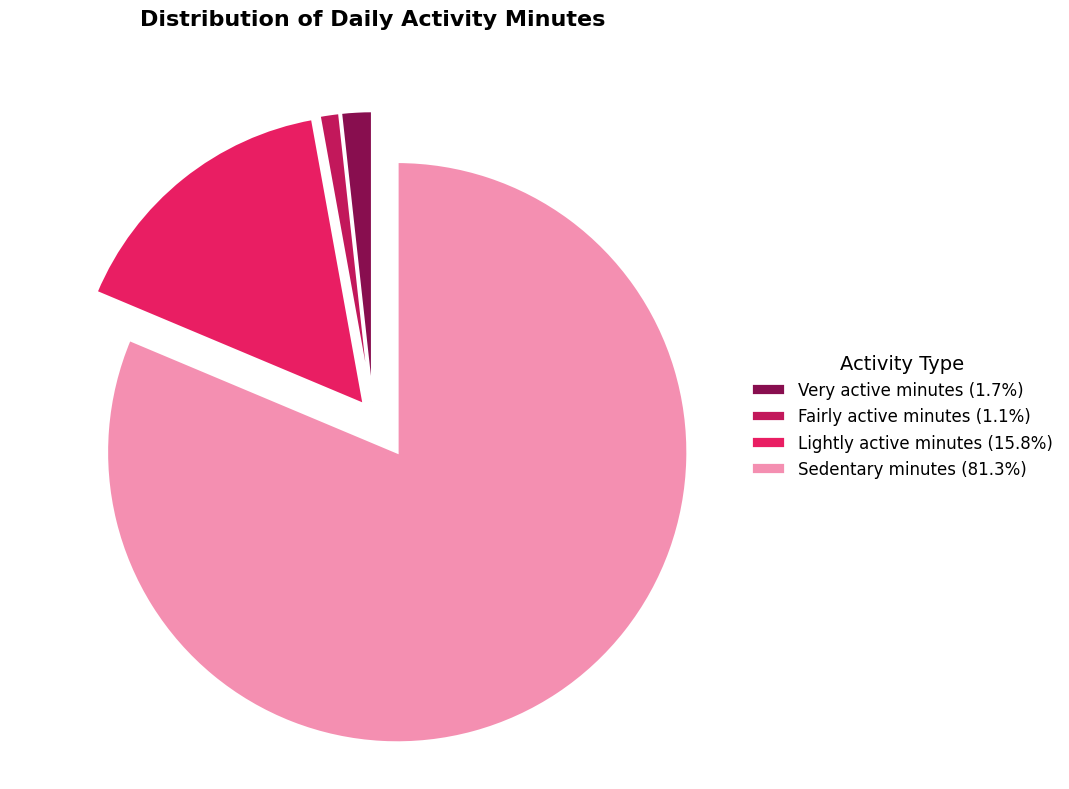

In [51]:
import matplotlib.pyplot as plt

very_active_mins = df['very_active_minutes'].sum()
fairly_active_mins = df['fairly_active_minutes'].sum()
lightly_active_mins = df['lightly_active_minutes'].sum()
sedentary_mins = df['sedentary_minutes'].sum()

slices = [very_active_mins, fairly_active_mins, lightly_active_mins, sedentary_mins]
labels = ["Very active minutes", "Fairly active minutes", "Lightly active minutes", "Sedentary minutes"]
colours = ["#880E4F", "#C2185B", "#E91E63", "#F48FB1"] 

total_mins = sum(slices)
legend_labels = []
for l, s in zip(labels, slices):
    percentage = (s / total_mins) * 100
    legend_labels.append(f'{l} ({percentage:.1f}%)')

plt.figure(figsize=(10, 8))

wedges, texts = plt.pie(
    slices,
    labels=None, 
    colors=colours, 
    wedgeprops={"edgecolor": "white", 'linewidth': 2}, 
    explode=[0.05, 0.05, 0.05, 0.15], 
    startangle=90
)

plt.legend(
    wedges,                  
    legend_labels,                
    title="Activity Type",
    loc="center left",       
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=12,
    title_fontsize=14,
    frameon=False 
)

plt.title("Distribution of Daily Activity Minutes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

##  Business Recommendations for Bellabeat Marketing Strategy
Based on the trends discovered, here are the high-level recommendations for the **Bellabeat App** and marketing campaigns

1. **Incentivize the 10k Goal (Smart Notifications):** 
   The Bellabeat app can send encouraging push notifications around mid-day if a user is far from reaching 10,000 steps, reminding them of the calorie-burning benefits.
   
2. **Target Inactive Days:** 
   Since data shows activity drops on Sundays, marketing campaigns and app reminders can  challenges to motivate users on typically lazy days.
   
3. **Sedentary Alerts for Office Workers:** 
   Because users spend a massive portion of their day being sedentary, Bellabeat can heavily market its **Leaf** or **Time** trackers as fashionable wellness assistants that gently vibrate to remind women to stand up and move after 1 hour of sitting.
   